In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
from scipy.optimize import curve_fit

def linear(x, a, b):
    return a * x + b

filepath = 'C:/Users/Ralph Group/Documents/Data/Orion/WisconsinBPBOPtCo/VICurve/'

In [5]:

filename = '4.47KIVbigHallAmputated_7I_min0max0.0007.csv'
ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))

Text(0.00042, 0.01, '420 microA')

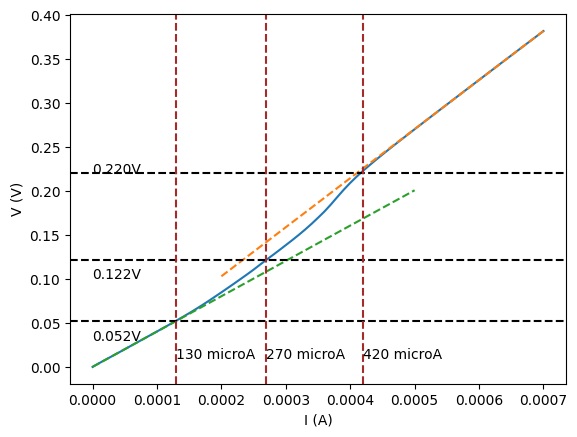

In [47]:
# fit linear slope to last 5 points of IV
xdata = ds.I.values[-20:]
ydata = ds.V.values[-20:]
popt, pcov = curve_fit(linear, xdata, ydata)

xdata = ds.I.values[:5]
ydata = ds.V.values[:5]
popt1, pcov1 = curve_fit(linear, xdata, ydata)

# plot IV curve
fig, ax = plt.subplots()
ax.plot(ds.I, ds.V)
fitrange = np.linspace(0.0002, ds.I.max(), 100)
ax.plot(fitrange, linear(fitrange, *popt), linestyle = '--')
fitrange2 = np.linspace(0, 0.0005, 100)
ax.plot(fitrange2, linear(fitrange2, *popt1), linestyle = '--')
plt.xlabel('I (A)')
plt.ylabel('V (V)')

# lines
plt.axhline(y=0.052, color='k', linestyle='--')
plt.axhline(y=0.122, color='k', linestyle='--')
plt.axhline(y=0.220, color='k', linestyle='--')
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

# put value of lines next to them
plt.text(0.000, 0.03, '0.052V')
plt.text(0.0000, 0.1, '0.122V')
plt.text(0.000, 0.22, '0.220V')
plt.text(0.00027, 0.01, '270 microA')
plt.text(0.00013, 0.01, '130 microA')
plt.text(0.00042, 0.01, '420 microA')


Text(0.00042, 0.01, '420 microA')

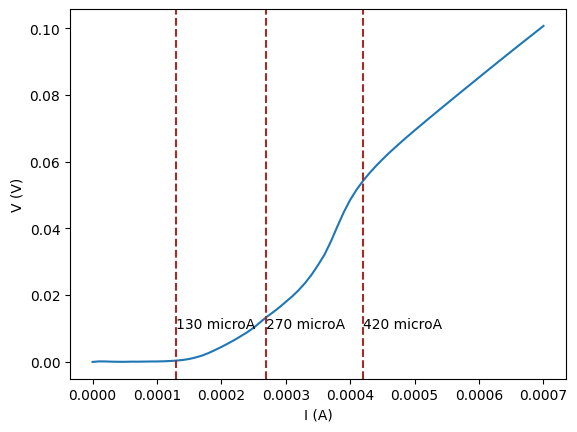

In [49]:
# fit linear slope to last 5 points of IV
xdata = ds.I.values[-20:]
ydata = ds.V.values[-20:]
popt, pcov = curve_fit(linear, xdata, ydata)

xdata = ds.I.values[:5]
ydata = ds.V.values[:5]
popt1, pcov1 = curve_fit(linear, xdata, ydata)

V_flat = ds.V - linear(ds.I, *popt1)

# plot IV curve
fig, ax = plt.subplots()
ax.plot(ds.I, V_flat)
# fitrange = np.linspace(0.0002, ds.I.max(), 100)
# ax.plot(fitrange, linear(fitrange, *popt), linestyle = '--')
# fitrange2 = np.linspace(0, 0.0005, 100)
# ax.plot(fitrange2, linear(fitrange2, *popt1), linestyle = '--')
plt.xlabel('I (A)')
plt.ylabel('V (V)')

# lines
# plt.axhline(y=0.052, color='k', linestyle='--')
# plt.axhline(y=0.122, color='k', linestyle='--')
# plt.axhline(y=0.220, color='k', linestyle='--')
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

# put value of lines next to them
# plt.text(0.000, 0.03, '0.052V')
# plt.text(0.0000, 0.1, '0.122V')
# plt.text(0.000, 0.22, '0.220V')
plt.text(0.00027, 0.01, '270 microA')
plt.text(0.00013, 0.01, '130 microA')
plt.text(0.00042, 0.01, '420 microA')


In [53]:
filepath = 'C:/Users/Ralph Group/Documents/Data/Orion/WisconsinBPBOPtCo/VICurve/'
filename = '4.47KIVbigHallAmputated_inplane_0.3T_43.68deg_2I_min-0.0007max0.0007.csv'
ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))

Text(0.00042, 0.01, '420 microA')

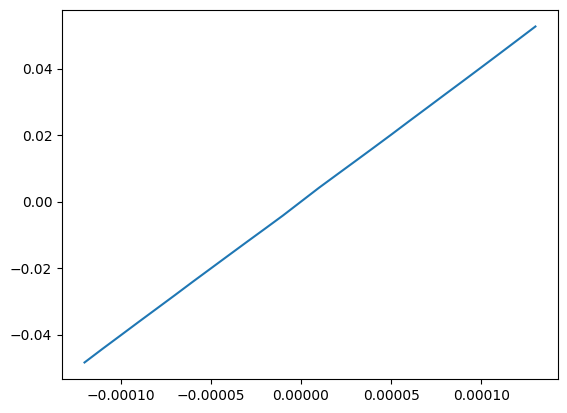

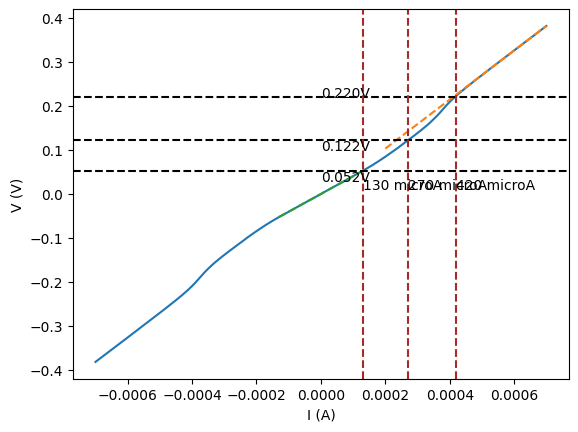

In [62]:
# fit linear slope to last 5 points of IV
xdata = ds.I.values[-20:]
ydata = ds.V.values[-20:]
popt, pcov = curve_fit(linear, xdata, ydata)

IFitrange = 130e-6
sel_ds = ds.where(ds.I > -IFitrange, drop = True)
sel_ds = sel_ds.where(sel_ds.I < IFitrange, drop = True)
xdata = sel_ds.I.values
ydata = sel_ds.V.values
plt.plot(xdata, ydata)
popt1, pcov1 = curve_fit(linear, xdata, ydata)

# plot IV curve
fig, ax = plt.subplots()
ax.plot(ds.I, ds.V)
fitrange = np.linspace(0.0002, ds.I.max(), 100)
ax.plot(fitrange, linear(fitrange, *popt), linestyle = '--')
fitrange2 = np.linspace(-IFitrange, IFitrange, 100)
ax.plot(fitrange2, linear(fitrange2, *popt1), linestyle = '--')
plt.xlabel('I (A)')
plt.ylabel('V (V)')

# lines
plt.axhline(y=0.052, color='k', linestyle='--')
plt.axhline(y=0.122, color='k', linestyle='--')
plt.axhline(y=0.220, color='k', linestyle='--')
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

# put value of lines next to them
plt.text(0.000, 0.03, '0.052V')
plt.text(0.0000, 0.1, '0.122V')
plt.text(0.000, 0.22, '0.220V')
plt.text(0.00027, 0.01, '270 microA')
plt.text(0.00013, 0.01, '130 microA')
plt.text(0.00042, 0.01, '420 microA')


Text(0.00042, 0.02, '420 microA')

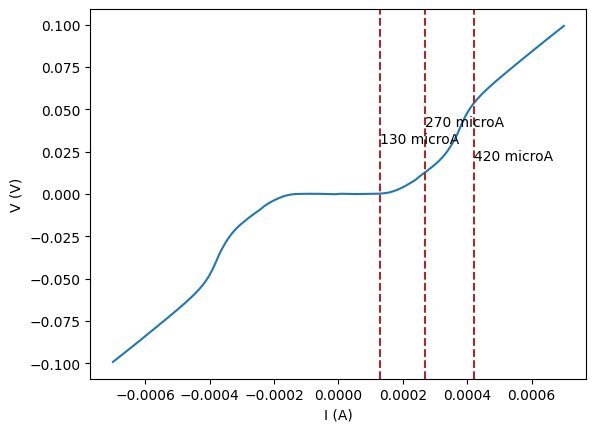

In [64]:
# fit linear slope to last 5 points of IV
V_flat = ds.V - linear(ds.I, *popt1)

# plot IV curve
fig, ax = plt.subplots()
ax.plot(ds.I, V_flat)
# fitrange = np.linspace(0.0002, ds.I.max(), 100)
# ax.plot(fitrange, linear(fitrange, *popt), linestyle = '--')
# fitrange2 = np.linspace(0, 0.0005, 100)
# ax.plot(fitrange2, linear(fitrange2, *popt1), linestyle = '--')
plt.xlabel('I (A)')
plt.ylabel('V (V)')

# lines
# plt.axhline(y=0.052, color='k', linestyle='--')
# plt.axhline(y=0.122, color='k', linestyle='--')
# plt.axhline(y=0.220, color='k', linestyle='--')
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

# put value of lines next to them
# plt.text(0.000, 0.03, '0.052V')
# plt.text(0.0000, 0.1, '0.122V')
# plt.text(0.000, 0.22, '0.220V')
plt.text(0.00027, 0.04, '270 microA')
plt.text(0.00013, 0.03, '130 microA')
plt.text(0.00042, 0.02, '420 microA')


In [2]:
filepath = 'C:/Users/Ralph Group/Documents/Data/Orion/WisconsinBPBOPtCo/VICurve/'
filename = '4.47KIVbigHallAmputated_inplane_0.9T_43.68degI_min-0.0007max0.0007.csv'
ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))

Text(0.00042, 0.01, '420 microA')

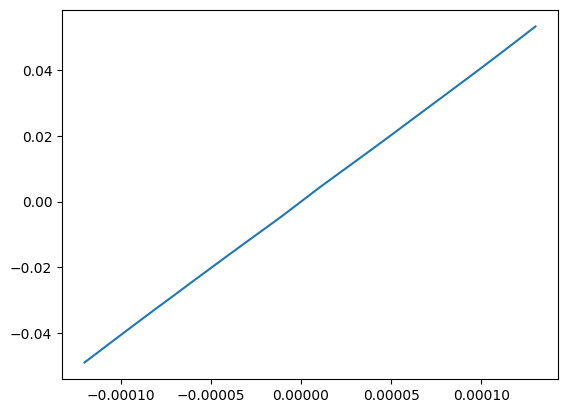

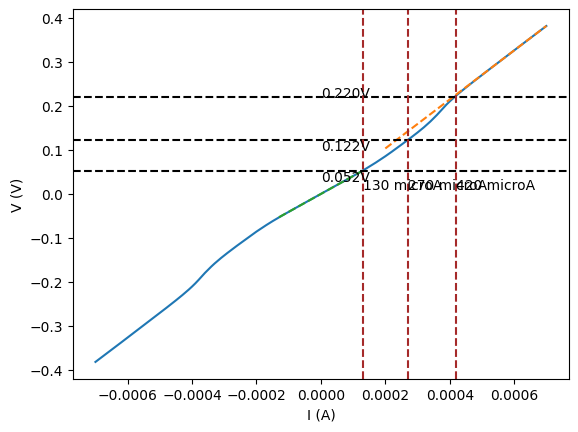

In [3]:
# plot IV curve
fig, ax = plt.subplots()
ax.plot(ds.I, ds.V)
fitrange = np.linspace(0.0002, ds.I.max(), 100)
ax.plot(fitrange, linear(fitrange, *popt), linestyle = '--')
fitrange2 = np.linspace(-IFitrange, IFitrange, 100)
ax.plot(fitrange2, linear(fitrange2, *popt1), linestyle = '--')
plt.xlabel('I (A)')
plt.ylabel('V (V)')

# lines
plt.axhline(y=0.052, color='k', linestyle='--')
plt.axhline(y=0.122, color='k', linestyle='--')
plt.axhline(y=0.220, color='k', linestyle='--')
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

# put value of lines next to them
plt.text(0.000, 0.03, '0.052V')
plt.text(0.0000, 0.1, '0.122V')
plt.text(0.000, 0.22, '0.220V')
plt.text(0.00027, 0.01, '270 microA')
plt.text(0.00013, 0.01, '130 microA')
plt.text(0.00042, 0.01, '420 microA')


Text(0.00042, 0.02, '420 microA')

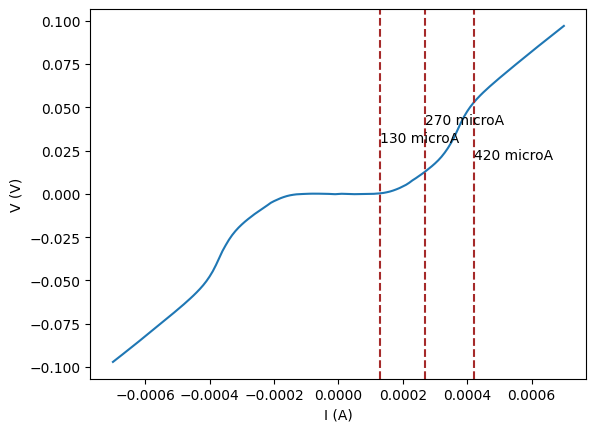

In [4]:
# fit linear slope to last 5 points of IV
V_flat = ds.V - linear(ds.I, *popt1)

# plot IV curve
fig, ax = plt.subplots()
ax.plot(ds.I, V_flat)
# fitrange = np.linspace(0.0002, ds.I.max(), 100)
# ax.plot(fitrange, linear(fitrange, *popt), linestyle = '--')
# fitrange2 = np.linspace(0, 0.0005, 100)
# ax.plot(fitrange2, linear(fitrange2, *popt1), linestyle = '--')
plt.xlabel('I (A)')
plt.ylabel('V (V)')

# lines
# plt.axhline(y=0.052, color='k', linestyle='--')
# plt.axhline(y=0.122, color='k', linestyle='--')
# plt.axhline(y=0.220, color='k', linestyle='--')
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

# put value of lines next to them
# plt.text(0.000, 0.03, '0.052V')
# plt.text(0.0000, 0.1, '0.122V')
# plt.text(0.000, 0.22, '0.220V')
plt.text(0.00027, 0.04, '270 microA')
plt.text(0.00013, 0.03, '130 microA')
plt.text(0.00042, 0.02, '420 microA')


In [52]:
# filename = '4.47KIVbigHallAmputated_inplane_0.3T_43.68deg_2I_min-0.0007max0.0007.csv'
# nofield_ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))

filename = '4.47K__IV__bigHallAmputated__satOOP__0.25T__inplane__0.00T__-46.32deg__I_min-0.0007max0.0007.csv'
nofield_ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))

def removebg(ds):
    # fit linear slope to last 5 points of IV
    xdata = ds.I.values[-20:]
    ydata = ds.V.values[-20:]
    popt, pcov = curve_fit(linear, xdata, ydata)

    IFitrange = 130e-6
    sel_ds = ds.where(ds.I > -IFitrange, drop = True)
    sel_ds = sel_ds.where(sel_ds.I < IFitrange, drop = True)
    xdata = sel_ds.I.values
    ydata = sel_ds.V.values
    # plt.plot(xdata, ydata)
    popt1, pcov1 = curve_fit(linear, xdata, ydata)
    ds = ds.assign(V_flat = ds.V - linear(ds.I, *popt1))
    return ds

Text(0.00042, 600, '420 microA')

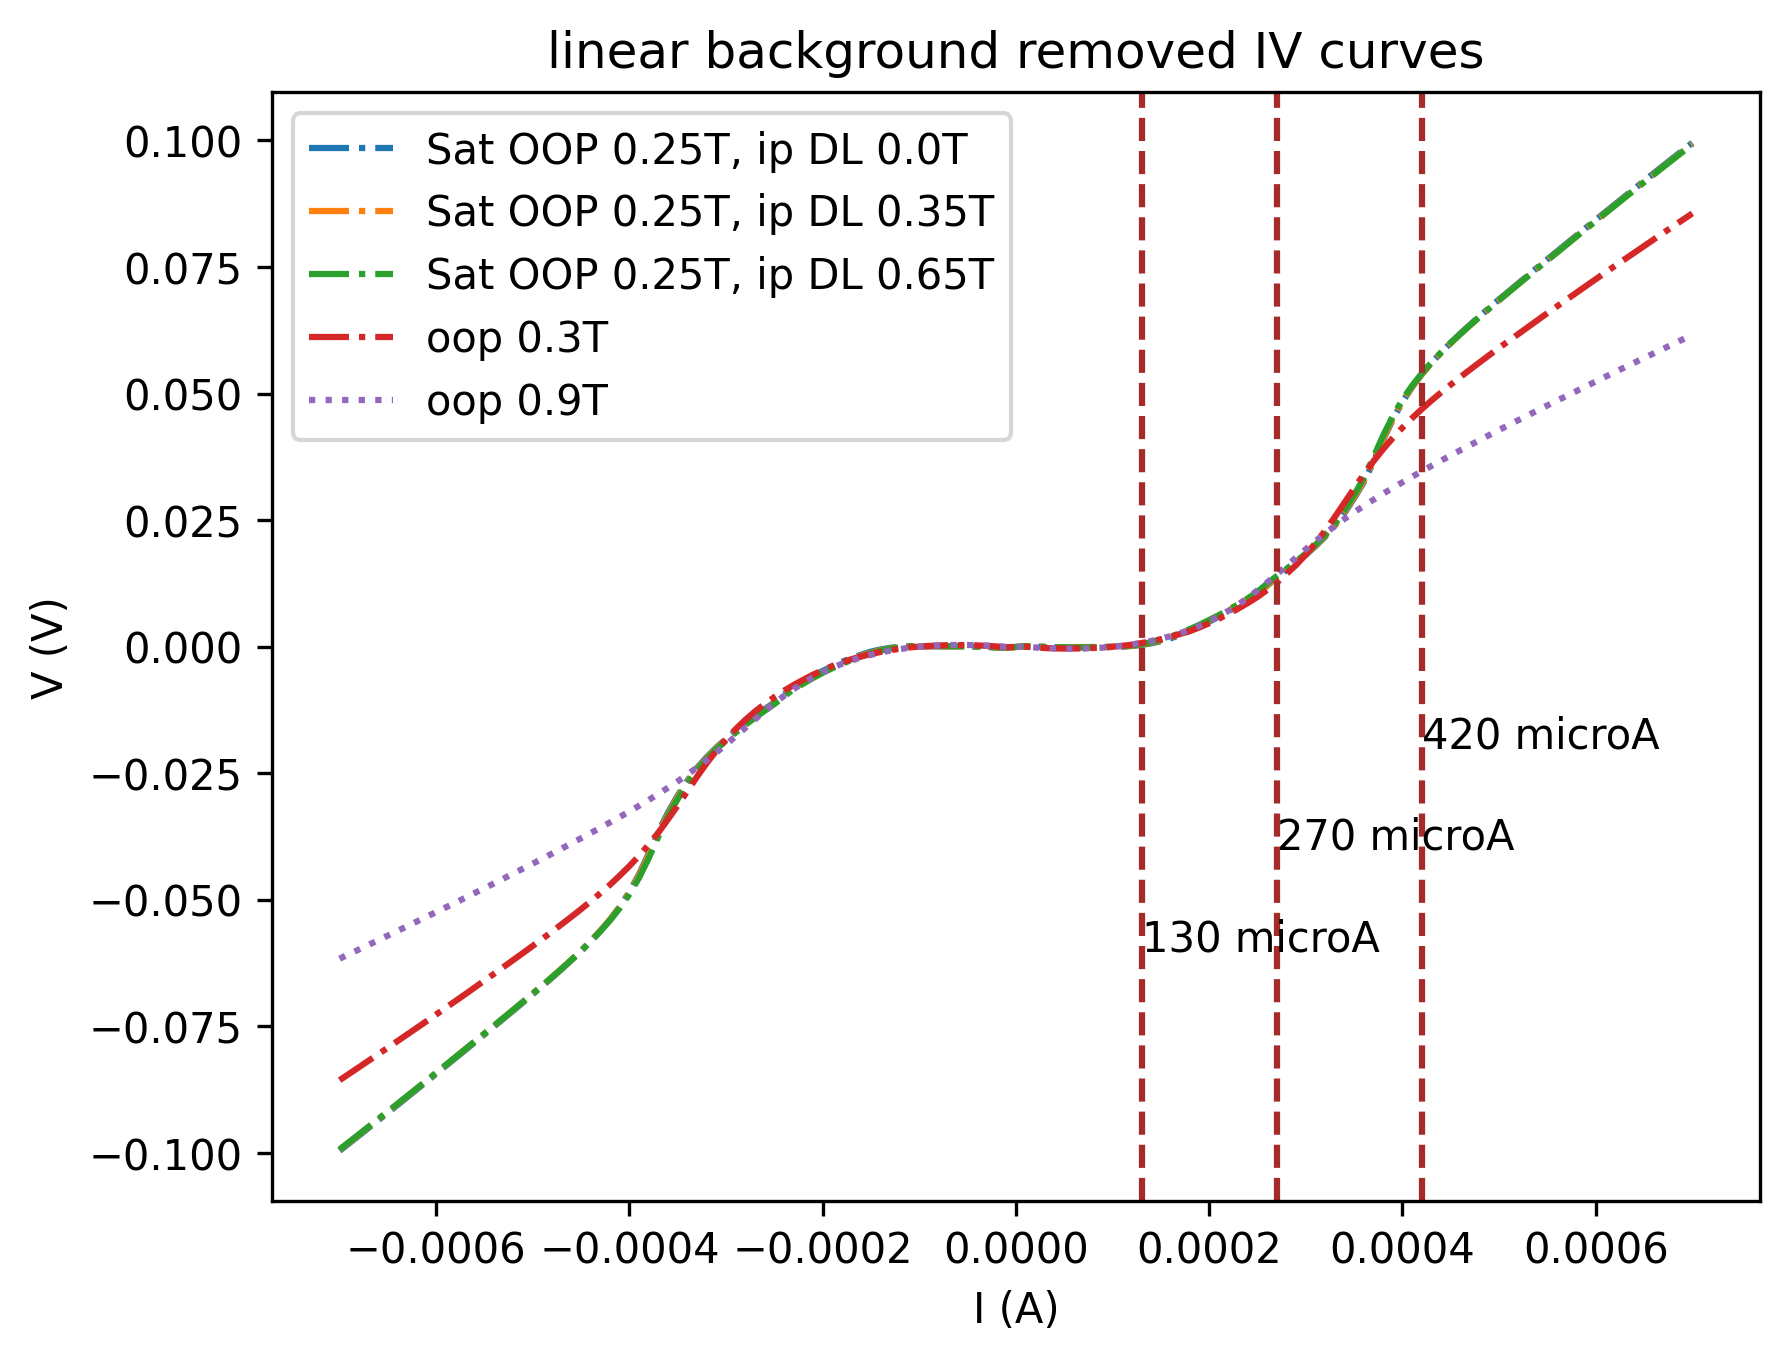

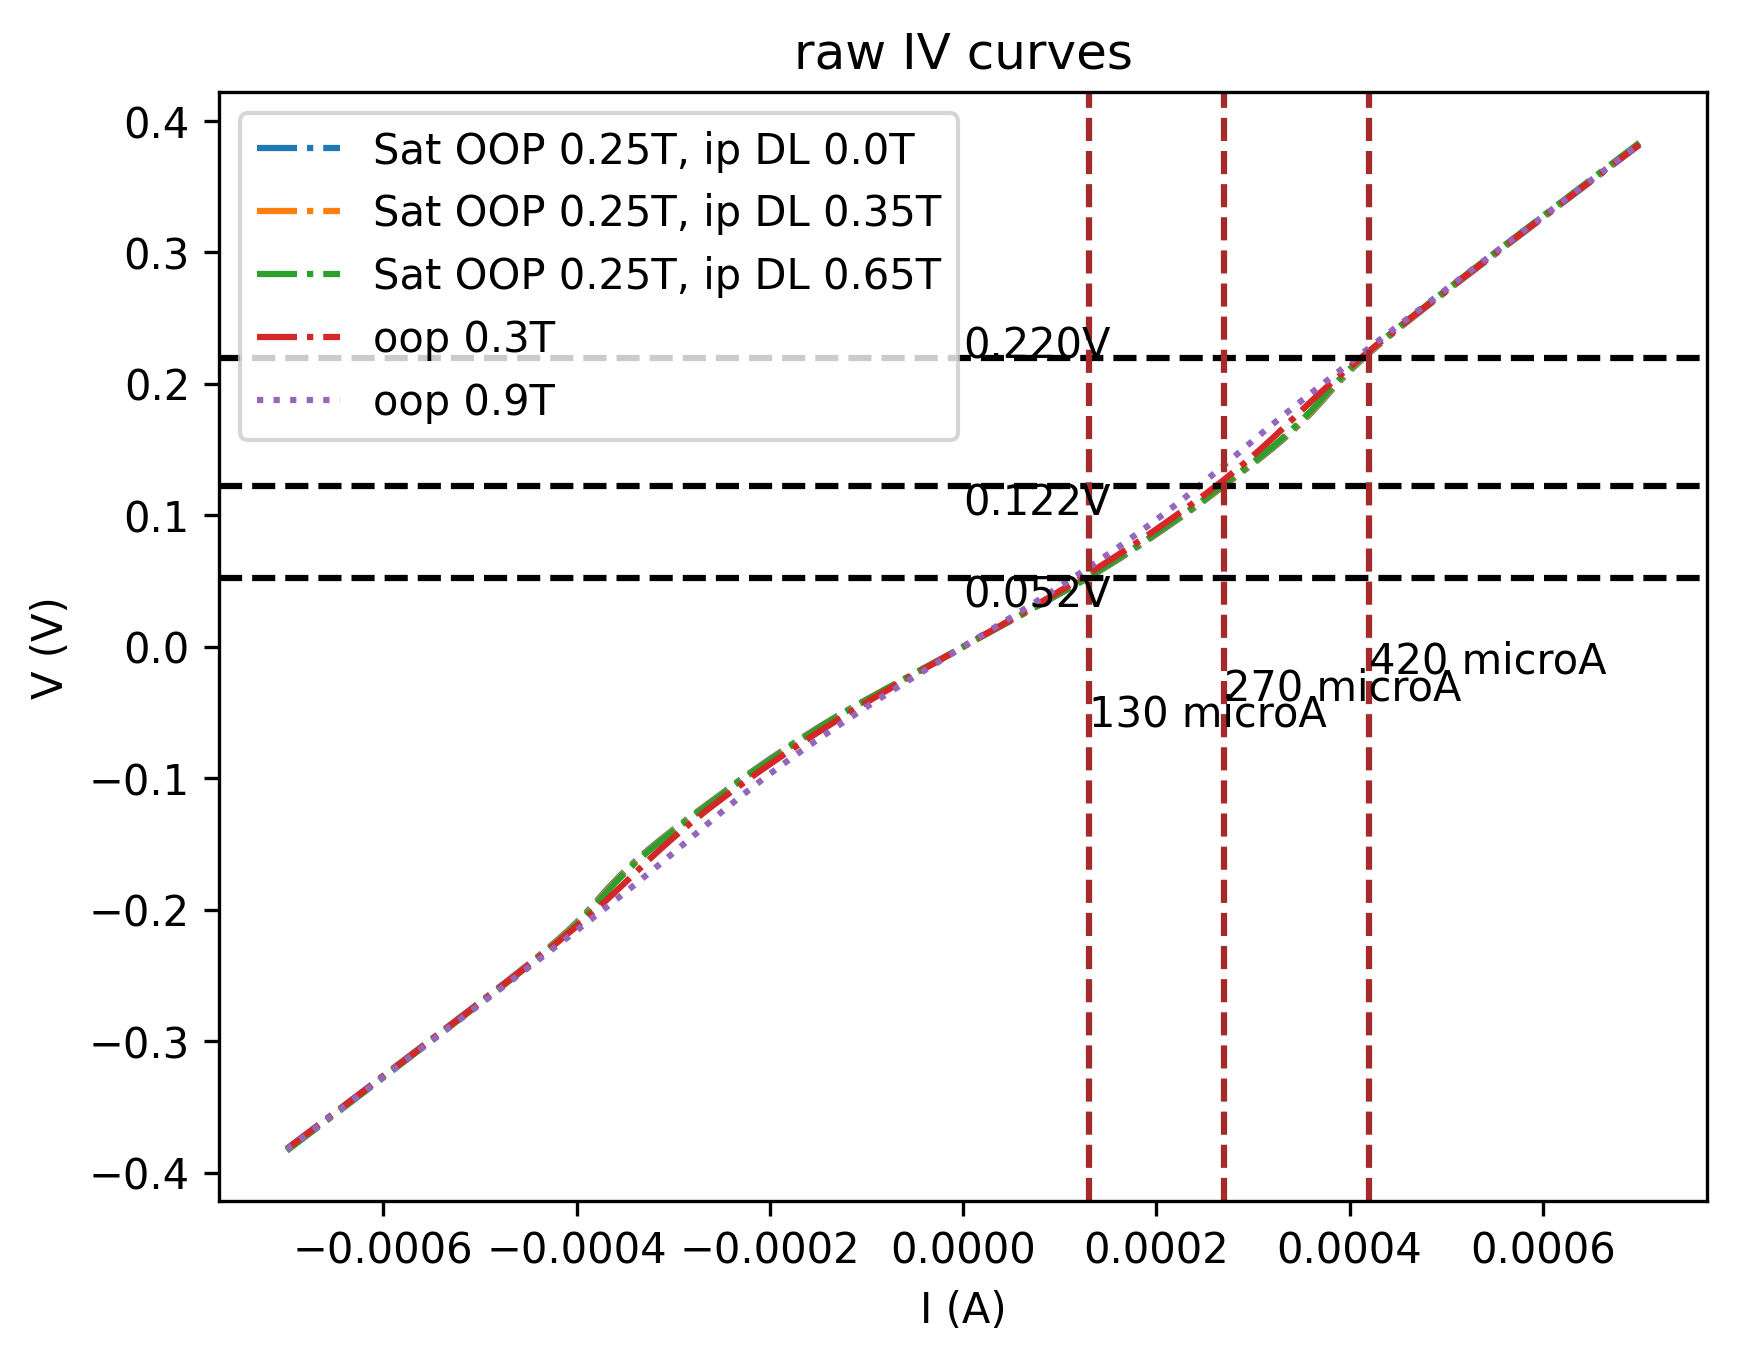

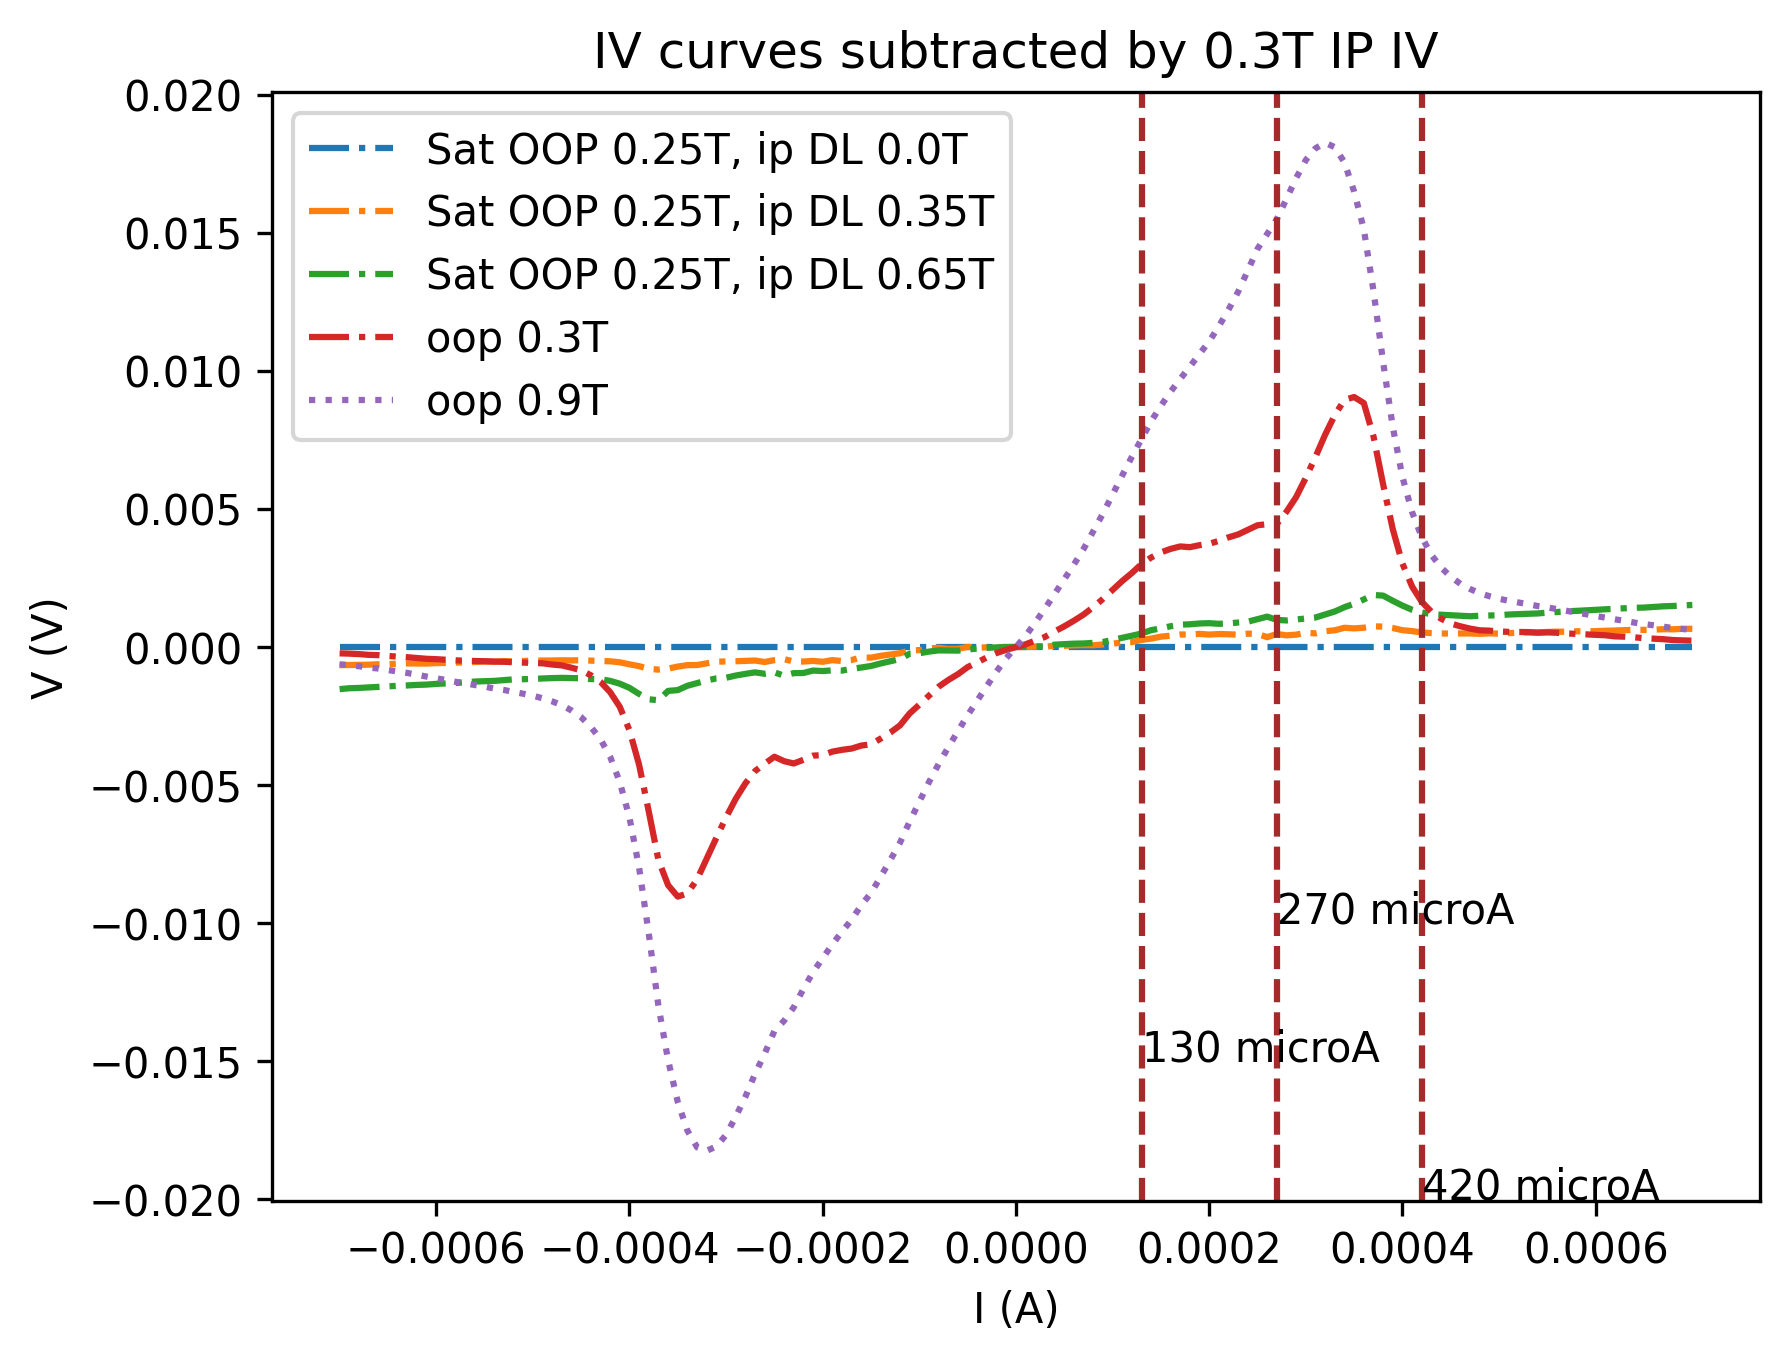

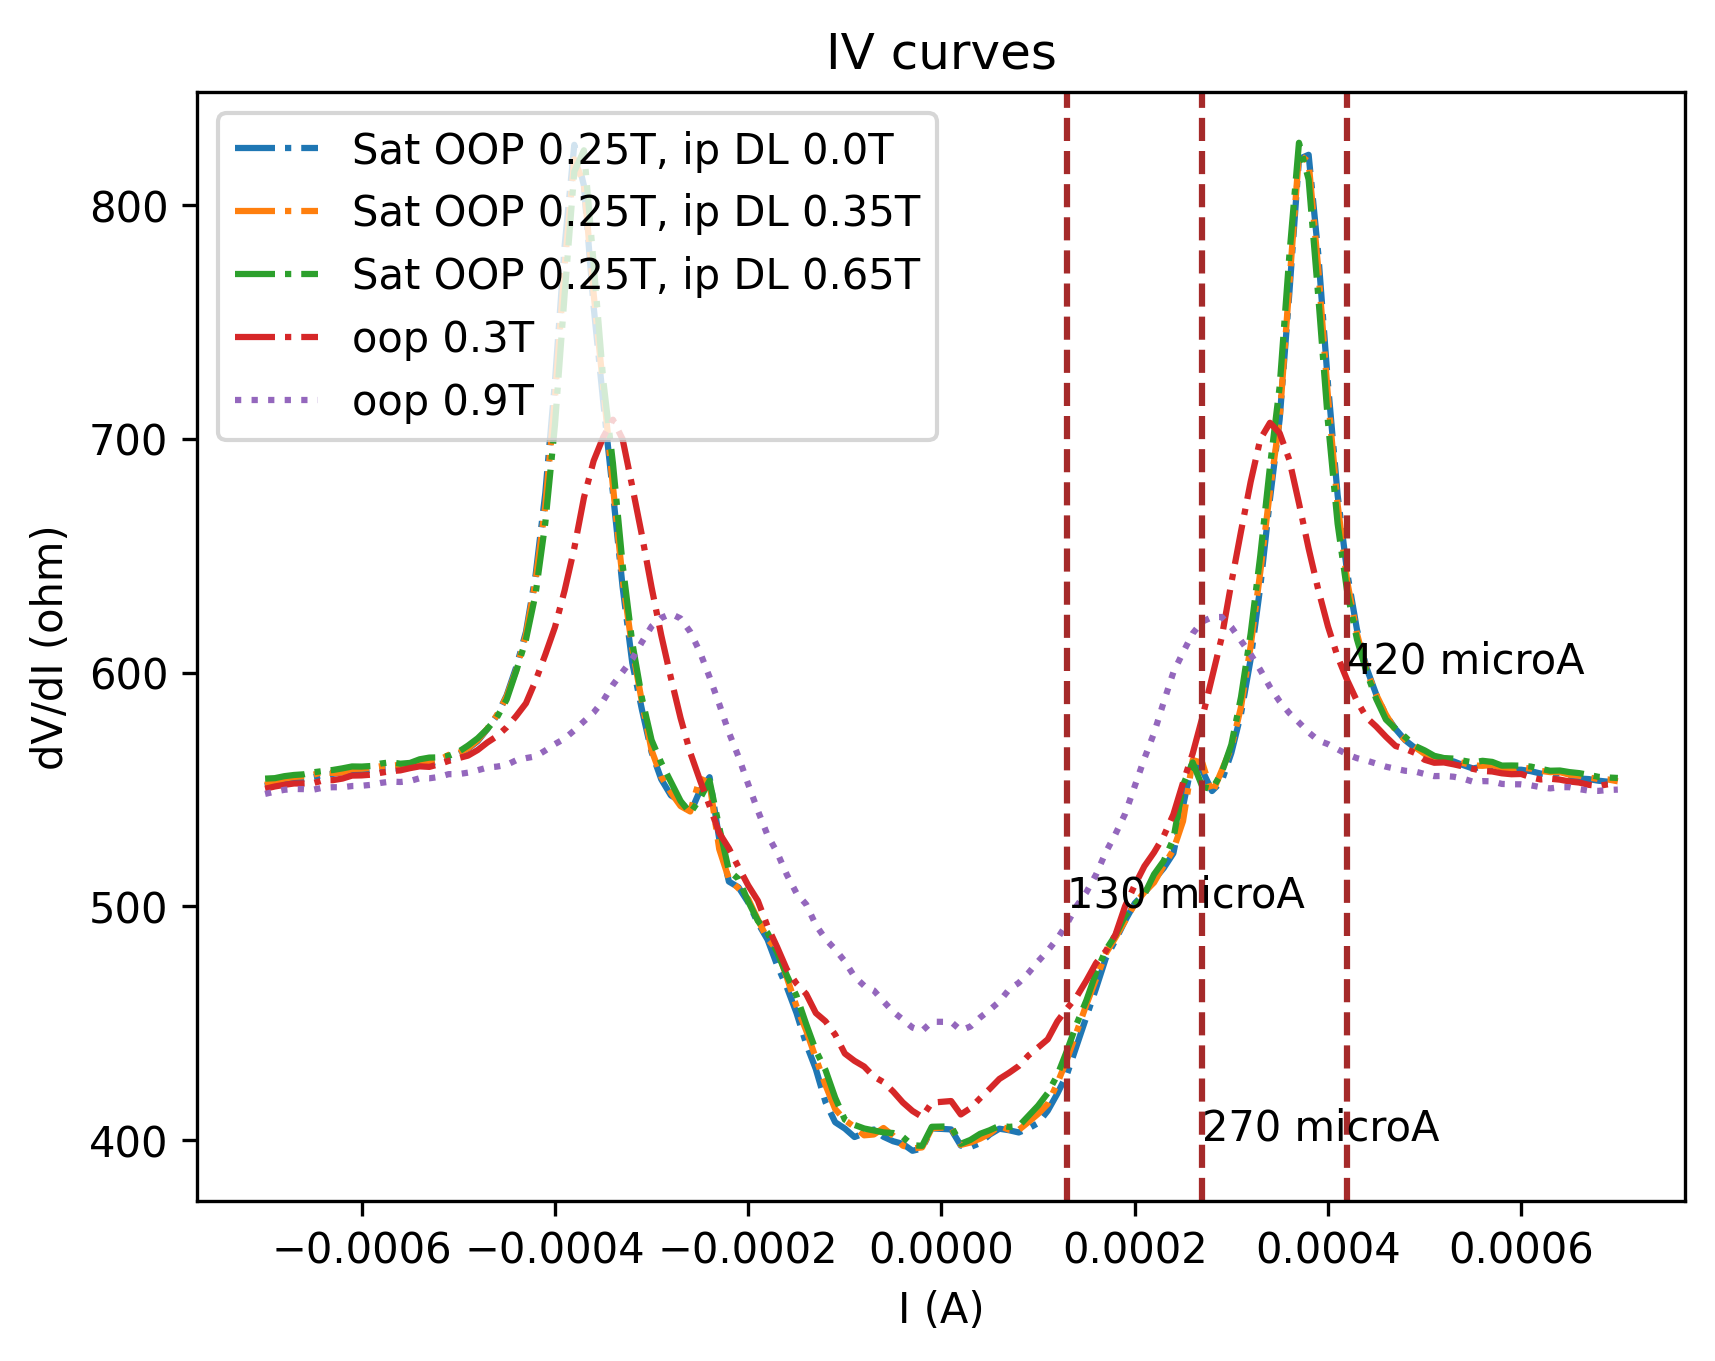

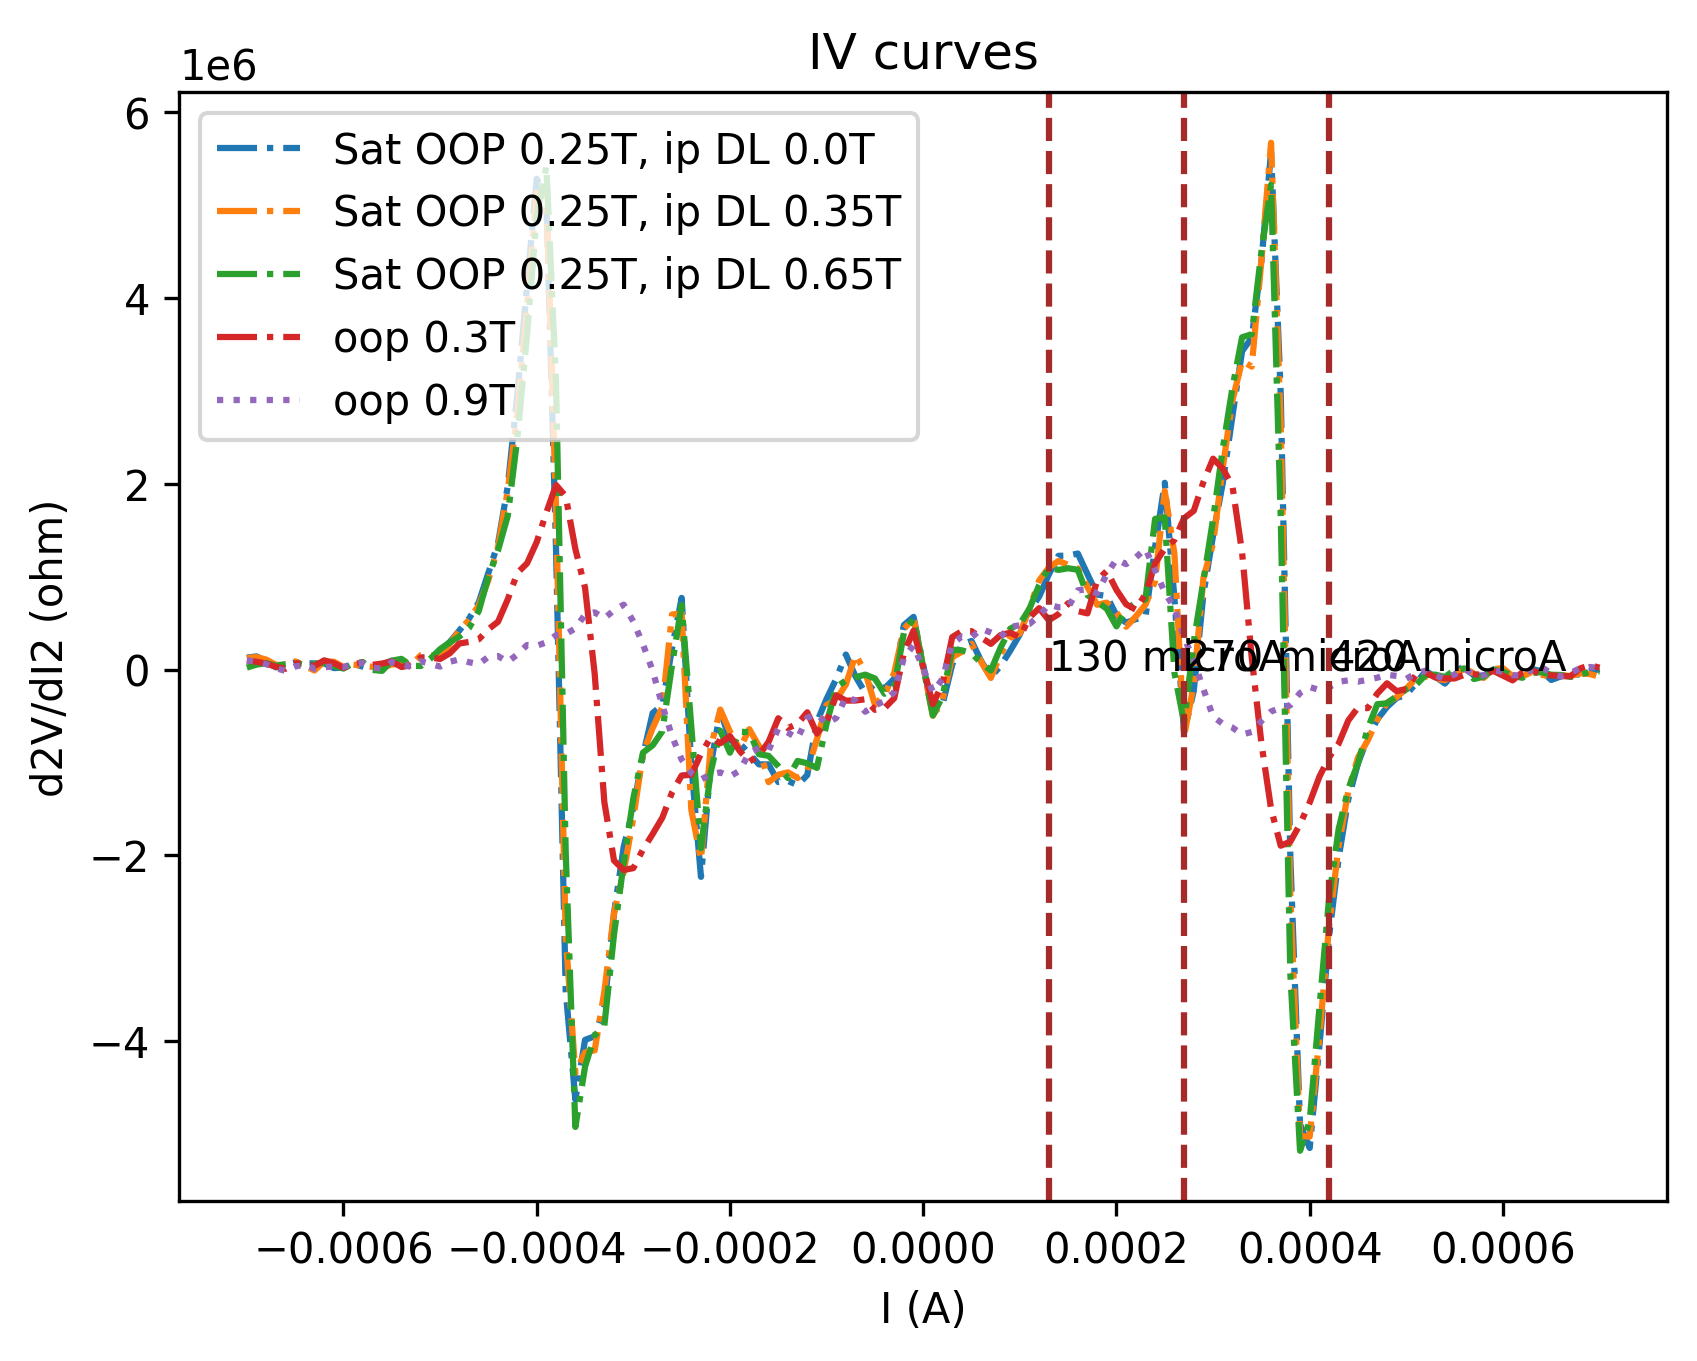

In [54]:
#increase dpi to 300
plt.rcParams['figure.dpi'] = 300


# filenames = ['4.47KIVbigHallAmputated_7I_min0max0.0007.csv',
#              '4.47KIVbigHallAmputated_inplane_0.3T_43.68deg_2I_min-0.0007max0.0007.csv', '4.47KIVbigHallAmputated_inplane_0.9T_43.68degI_min-0.0007max0.0007.csv',
#              '4.47KIVbigHallAmputated_inplane_0.3T_-46.32degI_min-0.0007max0.0007.csv', '4.47K__IV__bigHallAmputated__satOOP__0.25T__inplane__0.35T__-46.32deg__I_min-0.0007max0.0007.csv', '4.47K__IV__bigHallAmputated__satOOP__0.25T__inplane__0.65T__-46.32deg__I_min-0.0007max0.0007.csv', '4.47K__IV__bigHallAmputated__inplane___0.9T__-46.32deg__I_min-0.0007max0.0007.csv',
#              '4.47KIVbigHallAmputated_outofplane_0.3TI_min-0.0007max0.0007.csv', '4.47KIVbigHallAmputated_outofplane_0.9TI_min-0.0007max0.0007.csv']
# linestyles =['-', 
#              '--','--',
#              '-.','-.','-.','-.',
#              ':',':']
# labels = ['nofield', 
#           'ip FL 0.3T','ip FL 0.9T', 
#           'ip DL 0.3T', 'Sat OOP 0.25T, ip DL 0.35T', 'Sat OOP 0.25T, ip DL 0.65T',  'ip DL 0.9T', 
#           'oop 0.3T', 'oop 0.9T']

filenames = ['4.47K__IV__bigHallAmputated__satOOP__0.25T__inplane__0.00T__-46.32deg__I_min-0.0007max0.0007.csv','4.47K__IV__bigHallAmputated__satOOP__0.25T__inplane__0.35T__-46.32deg__I_min-0.0007max0.0007.csv', '4.47K__IV__bigHallAmputated__satOOP__0.25T__inplane__0.65T__-46.32deg__I_min-0.0007max0.0007.csv',
             '4.47KIVbigHallAmputated_outofplane_0.3TI_min-0.0007max0.0007.csv', '4.47KIVbigHallAmputated_outofplane_0.9TI_min-0.0007max0.0007.csv']

linestyles =['-.','-.','-.','-.',
             ':',':']

labels = ['Sat OOP 0.25T, ip DL 0.0T', 'Sat OOP 0.25T, ip DL 0.35T', 'Sat OOP 0.25T, ip DL 0.65T', 
          'oop 0.3T', 'oop 0.9T']

#plot IV curves
for i, filename in enumerate(filenames):
    ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))
    ds = removebg(ds)
    plt.figure(1)
    plt.plot(ds.I, ds.V_flat, linestyle = linestyles[i], label = labels[i])
    plt.legend()

plt.ylabel('V (V)')
plt.xlabel('I (A)')
plt.title('linear background removed IV curves')

plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

plt.text(0.00027, -0.04, '270 microA')
plt.text(0.00013, -0.06, '130 microA')
plt.text(0.00042, -0.02, '420 microA')






# fig, ax = plt.subplots()
for i, filename in enumerate(filenames):
    ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))
    # ds = removebg(ds)
    # plt.figure(0)
    # ax.plot(ds.I, ds.V, linestyle = linestyles[i])

    plt.figure(2)
    plt.plot(ds.I, ds.V, linestyle = linestyles[i], label = labels[i])
    plt.legend()

plt.ylabel('V (V)')
plt.xlabel('I (A)')
plt.title('raw IV curves')

# horizontal lines
plt.axhline(y=0.052, color='k', linestyle='--')
plt.axhline(y=0.122, color='k', linestyle='--')
plt.axhline(y=0.220, color='k', linestyle='--')

plt.text(0.000, 0.03, '0.052V')
plt.text(0.0000, 0.1, '0.122V')
plt.text(0.000, 0.22, '0.220V')

# vertical lines
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

plt.text(0.00027, -0.04, '270 microA')
plt.text(0.00013, -0.06, '130 microA')
plt.text(0.00042, -0.02, '420 microA')


for i, filename in enumerate(filenames):
    ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))
    ds = ds.assign(V_subtracted = ds.V - nofield_ds.V)

    plt.figure(3)
    plt.plot(ds.I, ds.V_subtracted, linestyle = linestyles[i], label = labels[i])
    plt.legend()

plt.ylabel('V (V)')
plt.xlabel('I (A)')
plt.title('IV curves subtracted by 0.3T IP IV')
# # horizontal lines
# plt.axhline(y=0.052, color='k', linestyle='--')
# plt.axhline(y=0.122, color='k', linestyle='--')
# plt.axhline(y=0.220, color='k', linestyle='--')

# plt.text(0.000, 0.03, '0.052V')
# plt.text(0.0000, 0.1, '0.122V')
# plt.text(0.000, 0.22, '0.220V')

# vertical lines
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

plt.text(0.00027, -0.01, '270 microA')
plt.text(0.00013, -0.015, '130 microA')
plt.text(0.00042, -0.02, '420 microA')



# Plot the derivatives
for i, filename in enumerate(filenames):
    ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))
    
    ds_derivative = np.gradient(ds.V, ds.I)
    



    # ds = removebg(ds)
    # plt.figure(0)
    # ax.plot(ds.I, ds.V, linestyle = linestyles[i])

    plt.figure(4)
    plt.plot(ds.I, ds_derivative, linestyle = linestyles[i], label = labels[i])
    plt.legend()

plt.ylabel('dV/dI (ohm)')
plt.xlabel('I (A)')
plt.title('IV curves')



# vertical lines
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

plt.text(0.00027, 400, '270 microA')
plt.text(0.00013, 500, '130 microA')
plt.text(0.00042, 600, '420 microA')




# Plot the derivatives
for i, filename in enumerate(filenames):
    ds = xr.Dataset(pd.read_csv(filepath + filename, index_col ='I'))
    
    ds_derivative = np.gradient(ds.V, ds.I)
    ds_derivative = np.gradient(ds_derivative, ds.I)
    



    # ds = removebg(ds)
    # plt.figure(0)
    # ax.plot(ds.I, ds.V, linestyle = linestyles[i])

    plt.figure(5)
    plt.plot(ds.I, ds_derivative, linestyle = linestyles[i], label = labels[i])
    plt.legend()

plt.ylabel('d2V/dI2 (ohm)')
plt.xlabel('I (A)')
plt.title('IV curves')



# vertical lines
plt.axvline(x=0.00013, color='brown', linestyle='--')
plt.axvline(x=0.00027, color='brown', linestyle='--')
plt.axvline(x=0.00042, color='brown', linestyle='--')

plt.text(0.00027, 400, '270 microA')
plt.text(0.00013, 500, '130 microA')
plt.text(0.00042, 600, '420 microA')